# Data Preprocessing

In [2]:
# import something you may find useful
import os, random

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split, Dataset, ConcatDataset
from torchvision import datasets, transforms, models
import numpy as np

import matplotlib
import matplotlib.pyplot as plt

# set seed
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)

# create a folder to save data
data_dir = "./data"
os.makedirs(data_dir, exist_ok=True)

Device: cpu


In [30]:
#imaget_norm consist of the mean and std of imagenet dataset
imagenet_norm = transforms.Normalize(
    mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225]
)

# The following class will be used to preprocess our data
# Every image in our dataset will be resized to 224x224 and converted to tensors
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    imagenet_norm
])

# Data Augmentation on the train dataset
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    imagenet_norm
])
    
    




## Loading the dataset

### Note: In the data split below, I merged the original train test val data into a single dataset, and then split them again using 60-20-20 rule. The original dataset didnot had enough observations in the validation set for me to validate the parameters.

In [31]:
batch_size = 64
# Load the original datasets
train_data_old = datasets.ImageFolder(root='./train', transform=transform)
val_data_old   = datasets.ImageFolder(root='./val', transform=transform)
test_data_old  = datasets.ImageFolder(root='./test', transform=transform)

# Merge them into one dataset
full_dataset = ConcatDataset([train_data_old, val_data_old, test_data_old])

In [32]:
total_len = len(full_dataset)
train_len = int(0.6 * total_len)
val_len = int(0.2 * total_len)
test_len = total_len - train_len - val_len

generator = torch.Generator().manual_seed(42)

train_data, val_data, test_data = random_split(
    full_dataset,
    [train_len, val_len, test_len],
    generator=generator
)
# Train dataset gets AUGMENTATION
train_data.dataset.transform = train_transform

# Val/test get ONLY resizing+normalization
val_data.dataset.transform = transform
test_data.dataset.transform = transform

batch_size = 64

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_data, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_data, batch_size=batch_size, shuffle=False)

In [33]:
len(train_data), len(val_data), len(test_data)

(3513, 1171, 1172)

# Feature extraction and Baselines / Progress Report Code

## In the following section, instead of using a CNN for image classification, we will be extracting features from our images using a pre-trained model, and then performing traditional ML models such as SVM, LR, and FNN.

In [4]:
# Load pretrained model
# feature extractor will be used to extract features from our images
resnet = models.resnet18(pretrained=True)
feature_extractor = torch.nn.Sequential(*list(resnet.children())[:-1])
feature_extractor.eval() 

/Users/muneebhassan/miniconda3/envs/my_py312_env/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/muneebhassan/miniconda3/envs/my_py312_env/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Con

In [5]:
# Function to extract features
def extract_features(dataset):
    
    loader = DataLoader(dataset, batch_size=32, shuffle=False)
    features, labels = [], []
    with torch.no_grad():
        for images, y in loader:
            outputs = feature_extractor(images)
            outputs = outputs.view(outputs.size(0), -1)  
            features.append(outputs.numpy())
            labels.append(y.numpy())
    
    X = np.concatenate(features)
    y = np.concatenate(labels)
    return X, y

In [6]:
# Extract features for all sets
X_train, y_train = extract_features(train_data)
X_val, y_val = extract_features(test_data)
X_test, y_test = extract_features(val_data)

In [7]:
# Convet the dataset to pandas dataframe
import pandas as pd
X_train_df = pd.DataFrame(X_train)
y_train_df = pd.DataFrame(y_train)
X_val_df = pd.DataFrame(X_val)
y_val_df = pd.DataFrame(y_val)
X_test_df = pd.DataFrame(X_test)
y_test_df = pd.DataFrame(y_test)

In [14]:
# --- Majority Baseline ---
from collections import Counter

def predict_majority_baseline(y_train, X_test, X_val):

    # 1. Count the occurrences of each class
    counts = Counter(y_train)

    count_0 = counts.get(0, 0)
    count_1 = counts.get(1, 0)

    # 2. Determine the majority class
    # If counts are equal, we arbitrarily choose 1 (or 0, the choice doesn't matter for the baseline accuracy)
    if count_1 >= count_0:
        majority_class = 1
    else:
        majority_class = 0

    # 3. Generate predictions for the test set
    num_test_samples_test = len(X_test)
    num_test_samples_val = len(X_val)
    predictions_test = np.full(num_test_samples_test, majority_class)
    predictions_val = np.full(num_test_samples_val, majority_class)

    return pd.DataFrame(predictions_test), pd.DataFrame(predictions_val)

In [15]:
# --- Logistic Regression Baseline ---
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Train
lr_model = LogisticRegression(max_iter=500, solver='lbfgs')
lr_model.fit(X_train_df, y_train_df)

# Evaluate on validation and test sets
for split, (X, y) in {
    "Validation": (X_val_df, y_val_df),
    "Test": (X_test_df, y_test_df)
}.items():
    preds = lr_model.predict(X)
    print(f"{split} Accuracy: {accuracy_score(y, preds):.4f}")
    print(f"{split} Report:\n", classification_report(y, preds))



/Users/muneebhassan/miniconda3/envs/my_py312_env/lib/python3.12/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Validation Accuracy: 0.7981
Validation Report:
               precision    recall  f1-score   support

           0       0.97      0.48      0.64       234
           1       0.76      0.99      0.86       390

    accuracy                           0.80       624
   macro avg       0.86      0.73      0.75       624
weighted avg       0.84      0.80      0.78       624

Test Accuracy: 0.8125
Test Report:
               precision    recall  f1-score   support

           0       1.00      0.62      0.77         8
           1       0.73      1.00      0.84         8

    accuracy                           0.81        16
   macro avg       0.86      0.81      0.81        16
weighted avg       0.86      0.81      0.81        16



In [10]:
# --- Support Vector Machine ---
from sklearn.svm import SVC

svm_model = SVC(kernel='rbf')
svm_model.fit(X_train_df, y_train_df)

svm_preds = svm_model.predict(X_test_df)
print(classification_report(y_test_df, svm_preds))


/Users/muneebhassan/miniconda3/envs/my_py312_env/lib/python3.12/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


              precision    recall  f1-score   support

           0       1.00      0.50      0.67         8
           1       0.67      1.00      0.80         8

    accuracy                           0.75        16
   macro avg       0.83      0.75      0.73        16
weighted avg       0.83      0.75      0.73        16



In [11]:
import torch
from torch import nn, optim

input_size = X_train_df.shape[1]
model = nn.Sequential(
    nn.Linear(input_size, 64),
    nn.ReLU(),
    nn.Linear(64, 1),
    nn.Sigmoid()
)

criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

X_train_tensor = torch.tensor(X_train_df.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_df.values.reshape(-1, 1), dtype=torch.float32)

for epoch in range(10):
    optimizer.zero_grad()
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    loss.backward()
    optimizer.step()
    print(f"Epoch {epoch+1}/10, Loss: {loss.item():.4f}")


X_test_tensor = torch.tensor(X_test_df.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_df.values.reshape(-1, 1), dtype=torch.float32)

with torch.no_grad():
    y_pred_tensor = model(X_test_tensor)
    y_pred = (y_pred_tensor.numpy() > 0.5).astype(int)  # convert probabilities → class labels

# Classification report & accuracy
print("FNN Test Accuracy:", accuracy_score(y_test_df, y_pred))
print(classification_report(y_test_df, y_pred))


Epoch 1/10, Loss: 0.6888
Epoch 2/10, Loss: 0.5964
Epoch 3/10, Loss: 0.5689
Epoch 4/10, Loss: 0.5112
Epoch 5/10, Loss: 0.4662
Epoch 6/10, Loss: 0.4437
Epoch 7/10, Loss: 0.4194
Epoch 8/10, Loss: 0.3841
Epoch 9/10, Loss: 0.3502
Epoch 10/10, Loss: 0.3266
FNN Test Accuracy: 0.5
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         8
           1       0.50      1.00      0.67         8

    accuracy                           0.50        16
   macro avg       0.25      0.50      0.33        16
weighted avg       0.25      0.50      0.33        16



/Users/muneebhassan/miniconda3/envs/my_py312_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/muneebhassan/miniconda3/envs/my_py312_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/muneebhassan/miniconda3/envs/my_py312_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.


/var/folders/g6/x02zlhmn64v6rtsp5q3rbx400000gn/T/ipykernel_51440/218071768.py:14: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  "No Pneumonia (0)": int((y_train_df == 0).sum() + (y_val_df == 0).sum() + (y_test_df == 0).sum()),
/var/folders/g6/x02zlhmn64v6rtsp5q3rbx400000gn/T/ipykernel_51440/218071768.py:15: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  "Pneumonia (1)": int((y_train_df == 1).sum() + (y_val_df == 1).sum() + (y_test_df == 1).sum())


Dataset Info:
Total Samples: 5856
Train Samples: 5216
Validation Samples: 624
Test Samples: 16
Feature Count: 512
Class Distribution: {'No Pneumonia (0)': 1583, 'Pneumonia (1)': 4273}
Model Performance Summary:


,Model,Validation Accuracy,Test Accuracy,F1 Score (Test)
0,Majority Baseline,0.3750,0.5000,0.0000
1,Logistic Regression,0.7981,0.8125,0.8421
2,SVM (RBF Kernel),0.8237,0.7500,0.8000
3,Feedforward NN (PyTorch),0.6651,0.5000,0.6667


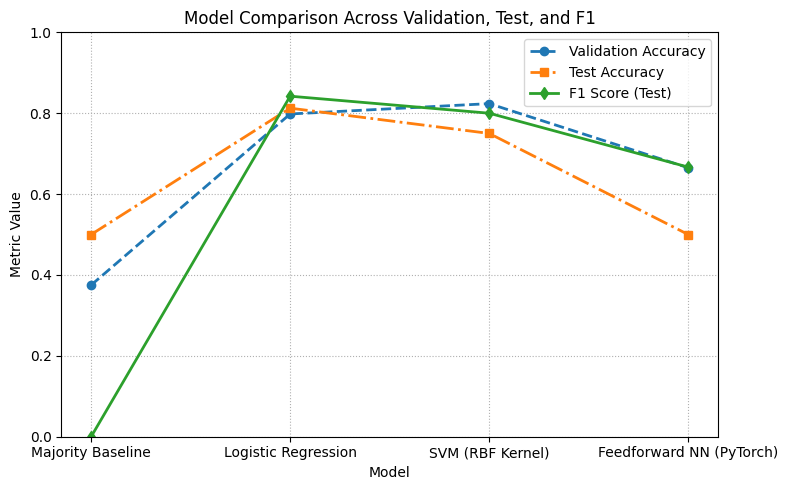

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score
import torch

dataset_info = {
    "Total Samples": len(X_train_df) + len(X_val_df) + len(X_test_df),
    "Train Samples": len(X_train_df),
    "Validation Samples": len(X_val_df),
    "Test Samples": len(X_test_df),
    "Feature Count": X_train_df.shape[1],
    "Class Distribution": {
        "No Pneumonia (0)": int((y_train_df == 0).sum() + (y_val_df == 0).sum() + (y_test_df == 0).sum()),
        "Pneumonia (1)": int((y_train_df == 1).sum() + (y_val_df == 1).sum() + (y_test_df == 1).sum())
    }
}

metrics = {}
# Majority Baseline
mb_test_preds, mb_val_preds = predict_majority_baseline(y_train_df, X_test_df, X_val_df)
metrics["Majority Baseline"] = {
    "Validation Accuracy": accuracy_score(y_val_df, mb_val_preds),
    "Test Accuracy": accuracy_score(y_test_df, mb_test_preds),
    "F1 Score (Test)": f1_score(y_test_df, mb_test_preds)
}


# Logistic Regression
lr_val_preds = lr_model.predict(X_val_df)
lr_test_preds = lr_model.predict(X_test_df)
metrics["Logistic Regression"] = {
    "Validation Accuracy": accuracy_score(y_val_df, lr_val_preds),
    "Test Accuracy": accuracy_score(y_test_df, lr_test_preds),
    "F1 Score (Test)": f1_score(y_test_df, lr_test_preds)
}

# SVM
svm_val_preds = svm_model.predict(X_val_df)
svm_test_preds = svm_model.predict(X_test_df)
metrics["SVM (RBF Kernel)"] = {
    "Validation Accuracy": accuracy_score(y_val_df, svm_val_preds),
    "Test Accuracy": accuracy_score(y_test_df, svm_test_preds),
    "F1 Score (Test)": f1_score(y_test_df, svm_test_preds)
}

# FNN (PyTorch)
with torch.no_grad():
    fnn_val_preds = (model(torch.tensor(X_val_df.values, dtype=torch.float32)).numpy() > 0.5).astype(int)
    fnn_test_preds = (model(torch.tensor(X_test_df.values, dtype=torch.float32)).numpy() > 0.5).astype(int)

metrics["Feedforward NN (PyTorch)"] = {
    "Validation Accuracy": accuracy_score(y_val_df, fnn_val_preds),
    "Test Accuracy": accuracy_score(y_test_df, fnn_test_preds),
    "F1 Score (Test)": f1_score(y_test_df, fnn_test_preds)
}

results_df = pd.DataFrame(metrics).T.reset_index().rename(columns={"index": "Model"}).round(4)


print("Dataset Info:")
for k, v in dataset_info.items():
    print(f"{k}: {v}")

print("Model Performance Summary:")
display(results_df)

models = results_df['Model']

plt.figure(figsize=(8,5))
plt.plot(models, results_df['Validation Accuracy'], 'o--', linewidth=2, label='Validation Accuracy')
plt.plot(models, results_df['Test Accuracy'], 's-.', linewidth=2, label='Test Accuracy')
plt.plot(models, results_df['F1 Score (Test)'], 'd-', linewidth=2, label='F1 Score (Test)')

plt.title('Model Comparison Across Validation, Test, and F1')
plt.xlabel('Model')
plt.ylabel('Metric Value')
plt.ylim(0, 1)
plt.grid(True, linestyle=':')
plt.legend()
plt.tight_layout()
plt.show()


# Building a CNN model on our dataset

In [7]:
# Define the network architecture
class pnuemoniaCNN(nn.Module):
    def __init__(self):
        super(pnuemoniaCNN, self).__init__()
        self.conv10 = nn.Conv2d(in_channels=3, out_channels=10, kernel_size=3, padding=1)
        self.pooling = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv5 = nn.Conv2d(in_channels=10, out_channels=5, kernel_size=3, padding=1)
        self.conv16 = nn.Conv2d(in_channels=5, out_channels=16, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(in_features = 16*56*56, out_features = 256)
        self.fc2 = nn.Linear(in_features = 256, out_features = 128)
        self.fc3 = nn.Linear(in_features = 128, out_features = 2)

    def forward(self, x):
        # CODE HERE
        # Implement the forward pass. Return the final output.
        x = self.conv10(x)
        x = F.relu(x)
        x = self.pooling(x)
        x = self.conv5(x)
        x = F.relu(x)
        x = self.conv16(x)
        x = F.relu(x)
        x = self.pooling(x)
        x = torch.flatten(x, 1) 
        x = self.fc1(x)
        x = F.relu(x)
        x = self.fc2(x)
        x = F.relu(x)
        x = self.fc3(x)
        out = F.log_softmax(x, dim=1)
        return out       

# You may want to verify the architecture of CNN
model = pnuemoniaCNN().to(device)
model

pnuemoniaCNN(
  (conv10): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pooling): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv5): Conv2d(10, 5, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv16): Conv2d(5, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=50176, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=2, bias=True)
)

In [8]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.005)  # Use a low learning rate for this dataset

model = model.to(device)


In [12]:
# Training Loop

from tqdm import tqdm # This library shows loading bar for each training epoch
def train_one_epoch(model, train_loader, optimizer, criterion, device):
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    pbar = tqdm(train_loader, desc=f"Training Epoch {epoch}/{epochs}")
    
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, pred = torch.max(outputs, 1)
        correct += pred.eq(labels).sum().item()
        total += images.size(0)

        pbar.set_postfix(loss=loss.item(), accuracy=f"{(correct/total)*100:.2f}%")

    return running_loss / len(train_loader.dataset), (correct / total) * 100

def evaluate(model, val_loader, criterion, device):
    model.eval()
    running_loss = 0
    correct = 0
    total = 0

    vbar = tqdm(val_loader, desc=f"Validation Epoch {epoch}/{epochs}")

    with torch.no_grad():
        for images, labels in vbar:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            _, pred = torch.max(outputs, 1)
            correct += pred.eq(labels).sum().item()
            total += images.size(0)

            vbar.set_postfix(val_loss=loss.item(), val_accuracy=f"{(correct/total)*100:.2f}%")

    return running_loss / len(val_loader.dataset), (correct / total) * 100

In [13]:
epochs = 7
train_losses, val_losses, train_accs, val_accs = [], [], [], []

# Run the training epochs
for epoch in range(1, epochs + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    va_loss, va_acc = evaluate(model, val_loader, criterion, device)
    train_losses.append(tr_loss)
    train_accs.append(tr_acc)
    val_losses.append(va_loss)
    val_accs.append(va_acc)

Training Epoch 1/7: 100%|█| 55/55 [00:45<00:00,  1.21it/s, accuracy=68.86%, loss
Validation Epoch 1/7: 100%|█| 19/19 [00:10<00:00,  1.78it/s, val_accuracy=72.76%
Training Epoch 2/7: 100%|█| 55/55 [00:46<00:00,  1.19it/s, accuracy=73.38%, loss
Validation Epoch 2/7: 100%|█| 19/19 [00:10<00:00,  1.76it/s, val_accuracy=72.76%
Training Epoch 3/7: 100%|█| 55/55 [00:46<00:00,  1.18it/s, accuracy=76.86%, loss
Validation Epoch 3/7: 100%|█| 19/19 [00:10<00:00,  1.74it/s, val_accuracy=84.37%
Training Epoch 4/7: 100%|█| 55/55 [00:47<00:00,  1.17it/s, accuracy=87.36%, loss
Validation Epoch 4/7: 100%|█| 19/19 [00:11<00:00,  1.65it/s, val_accuracy=82.49%
Training Epoch 5/7: 100%|█| 55/55 [00:46<00:00,  1.18it/s, accuracy=87.62%, loss
Validation Epoch 5/7: 100%|█| 19/19 [00:10<00:00,  1.78it/s, val_accuracy=82.32%
Training Epoch 6/7: 100%|█| 55/55 [00:46<00:00,  1.17it/s, accuracy=89.50%, loss
Validation Epoch 6/7: 100%|█| 19/19 [00:10<00:00,  1.74it/s, val_accuracy=92.14%
Training Epoch 7/7: 100%|█| 

In [14]:
test_loss, test_acc = evaluate(model, test_loader, criterion, device)

print(f"[Chest X-Ray Pneumonia Test] Loss = {test_loss:.4f} | Acc = {test_acc:.2f}%")

Validation Epoch 7/7: 100%|█| 19/19 [00:10<00:00,  1.80it/s, val_accuracy=88.23%

[Chest X-Ray Pneumonia Test] Loss = 0.2878 | Acc = 88.23%


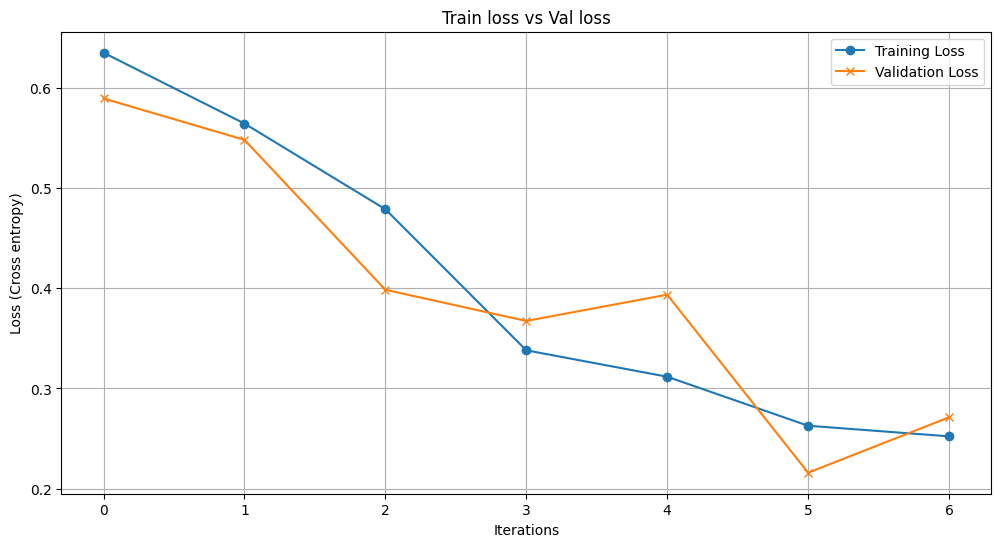

In [15]:
# CODE HERE
# Plot the "Training vs Validation Loss"
# --- Plotting Results ---
plt.figure(figsize=(12, 6))
plt.plot(train_losses, label='Training Loss', marker='o')
plt.plot(val_losses, label='Validation Loss', marker='x')
plt.title('Train loss vs Val loss')
plt.xlabel('Iterations')
plt.ylabel('Loss (Cross entropy)')
plt.legend()
plt.grid(True)
plt.show()



# Error Analysis

In [19]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

model.eval()
all_labels = []
all_preds = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="CNN Error Analysis on Test Set"):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

all_labels = np.array(all_labels)
all_preds = np.array(all_preds)

print("CNN Classification Report on Test Set:")
print(classification_report(all_labels, all_preds, target_names=["Normal", "Pneumonia"]))


CNN Error Analysis on Test Set: 100%|███████████| 19/19 [00:11<00:00,  1.72it/s]

CNN Classification Report on Test Set:
              precision    recall  f1-score   support

      Normal       0.73      0.93      0.82       329
   Pneumonia       0.97      0.86      0.91       843

    accuracy                           0.88      1172
   macro avg       0.85      0.90      0.86      1172
weighted avg       0.90      0.88      0.89      1172



<Figure size 400x400 with 0 Axes>

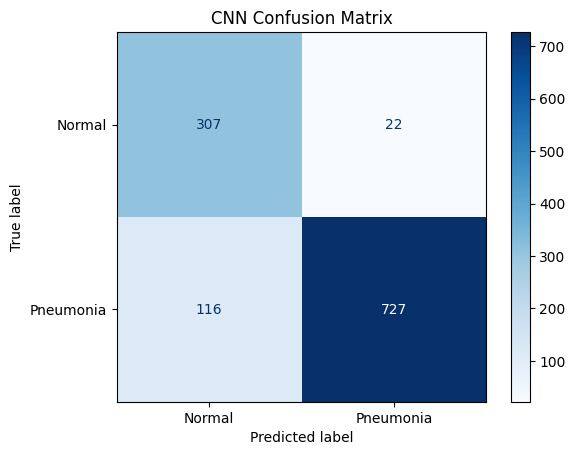

In [20]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(4, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Pneumonia"])
disp.plot(cmap=plt.cm.Blues)
plt.title("CNN Confusion Matrix")
plt.show()

In [34]:
# Undo the image normalizaton before displaying misclassified images
imagenet_mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
imagenet_std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

def denorm(img_tensor):
    img = img_tensor.cpu().clone()
    img = img * imagenet_std + imagenet_mean
    img = torch.clamp(img, 0, 1)
    return img

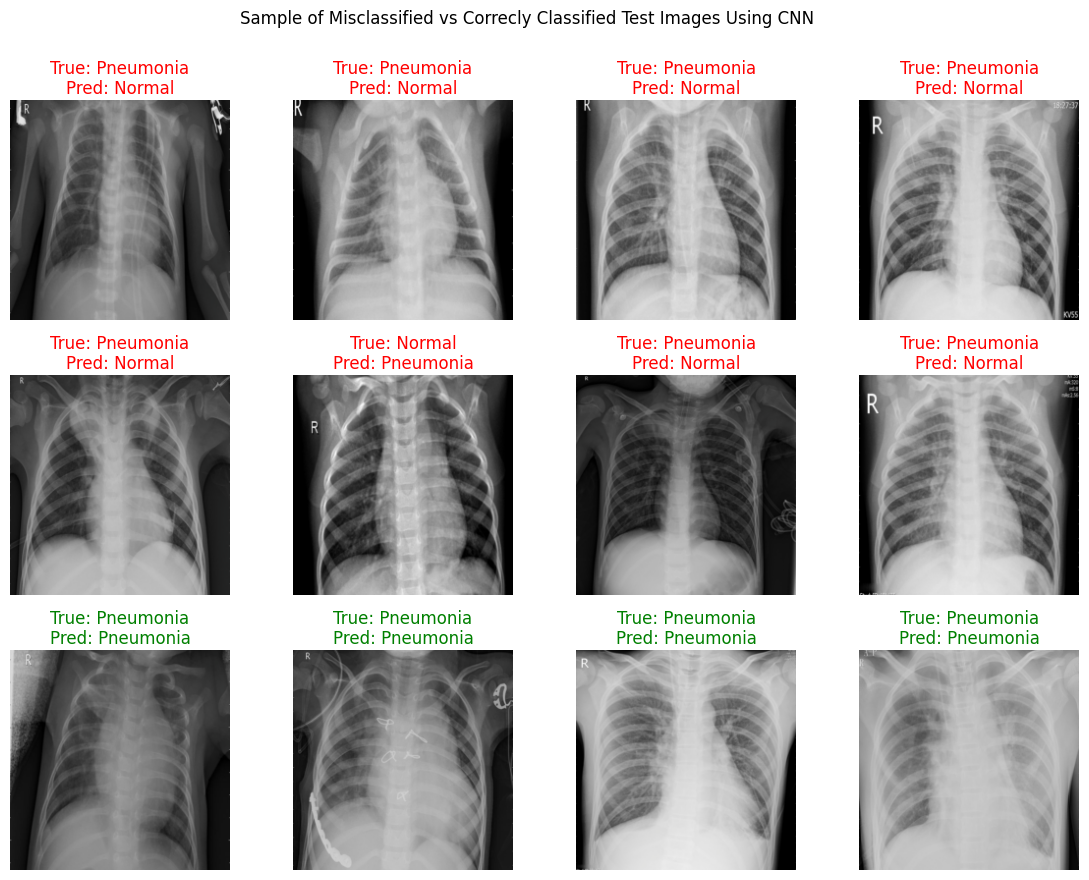

In [49]:
mis_images = [] # all misclassified images
mis_true = [] # true labels for misclassified images
mis_pred = [] # predicted labels for misclassified 

correct_images = []
correct_true = []
correct_pred = []

model.eval()
with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Collecting misclassified samples"):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        mask = preds != labels
        mask_correct = preds == labels
        
        mis_images.append(images[mask].cpu())
        mis_true.extend(labels[mask].cpu().numpy())
        mis_pred.extend(preds[mask].cpu().numpy())

        correct_images.append(images[mask_correct].cpu())
        correct_true.extend(labels[mask_correct].cpu().numpy())
        correct_pred.extend(preds[mask_correct].cpu().numpy())

    mis_images = torch.cat(mis_images, dim=0)
    correct_images = torch.cat(correct_images, dim=0)
    
    # Shuffle through the misclassified images
    mis_indices = torch.randperm(len(mis_images))
    mis_images = mis_images[mis_indices]
    mis_true = np.array(mis_true)[mis_indices]
    mis_pred = np.array(mis_pred)[mis_indices]

    corr_indices = torch.randperm(len(correct_images))
    correct_images = correct_images[corr_indices]
    correct_true = np.array(correct_true)[corr_indices]
    correct_pred = np.array(correct_pred)[corr_indices]
    
    num_mis_display = min(8, len(mis_images)) # Display up to 8 misclassified images
    num_corr_display = min(4, len(correct_images)) # Display some correctly classified images for comparison
    plt.figure(figsize=(14, 10))
    
    for i in range(num_mis_display):
        plt.subplot(3, 4, i + 1)
        img = denorm(mis_images[i])
        img = img.permute(1, 2, 0).numpy()

        plt.imshow(img.squeeze(), cmap="gray", vmin=0.0, vmax=1.0)
        plt.axis("off")
        true_label = "Normal" if mis_true[i] == 0 else "Pneumonia"
        pred_label = "Normal" if mis_pred[i] == 0 else "Pneumonia"
        plt.title(f"True: {true_label}\nPred: {pred_label}", color="red", pad=4)

    offset = num_mis_display
    for i in range(num_corr_display):
        plt.subplot(3, 4, offset + i + 1)
        img = denorm(correct_images[i]).permute(1, 2, 0).numpy()
        plt.imshow(img.squeeze(), cmap="gray", vmin=0.0, vmax=1.0)
        plt.axis("off")
        true_label = "Normal" if correct_true[i] == 0 else "Pneumonia"
        pred_label = "Normal" if correct_pred[i] == 0 else "Pneumonia"
        plt.title(f"True: {true_label}\nPred: {pred_label}", color="green", pad=4)

    plt.suptitle("Sample of Misclassified vs Correcly Classified Test Images Using CNN", y=0.97)
    plt.subplots_adjust(top=0.88, hspace=0.25)
    plt.show()

CNN Performance Summary:


,Value
Validation Accuracy,0.8822
Test Accuracy,0.8823
F1 Score (Test),0.9133


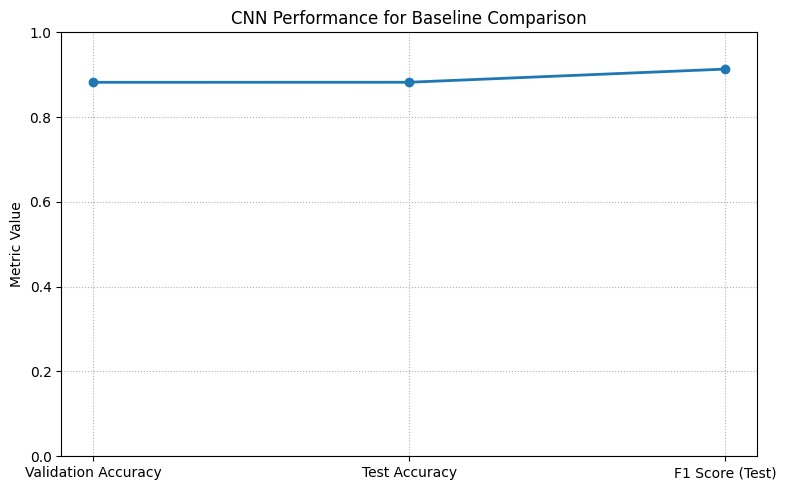

In [45]:
from sklearn.metrics import f1_score
import pandas as pd

cnn_val_acc = val_accs[-1] / 100.0    
cnn_test_acc = test_acc / 100.0      
cnn_f1 = f1_score(all_labels, all_preds)

print("CNN Performance Summary:")

cnn_metrics = {
    "Validation Accuracy": cnn_val_acc,
    "Test Accuracy": cnn_test_acc,
    "F1 Score (Test)": cnn_f1
}

cnn_df = pd.DataFrame.from_dict(cnn_metrics, orient='index', columns=['Value']).round(4)
display(cnn_df)

labels = list(cnn_metrics.keys())
values = list(cnn_metrics.values())

plt.figure(figsize=(8, 5))
plt.plot(labels, values, marker='o', linewidth=2)
plt.title('CNN Performance for Baseline Comparison')
plt.ylabel('Metric Value')
plt.ylim(0, 1)
plt.grid(True, linestyle=':')
plt.tight_layout()
plt.show()